   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                   11                    34   0.9978  3.51       0.56   
1                   25                    67   0.9968  3.20       0.68   
2                   15                    54   0.9970  3.26       0.65   
3                   17                    60   0.9980  3.16       0.58   
4                   11                    34   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

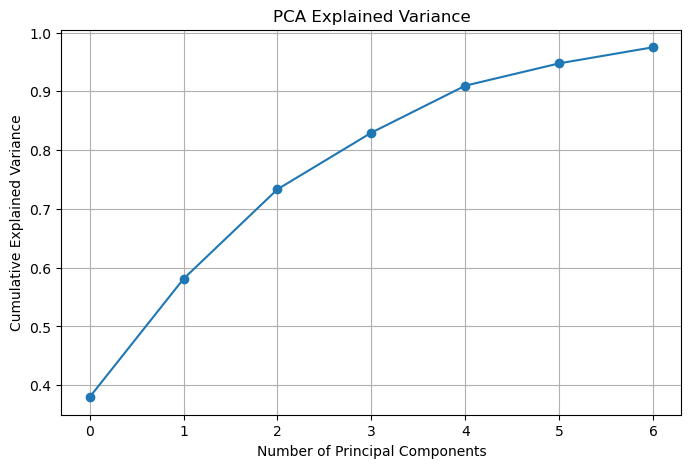


Accuracy:
0.75

Confusion Matrix:
[[3 0 0]
 [0 0 0]
 [0 1 0]]

Classification Report:
              precision    recall  f1-score   support

           5       1.00      1.00      1.00         3
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.33      0.33      0.33         4
weighted avg       0.75      0.75      0.75         4


10-Fold Cross Validation Accuracy Scores:
[1.  1.  0.  0.5 1.  1.  0.5 1.  1.  1. ]

Mean Accuracy: 0.8000
Standard Deviation: 0.3317

Model saved successfully.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = pd.read_csv(r"D:\Python-Course\ML-Course\test\wine_quality_pca_dataset.csv")
print(data.head())
print("\nDataset Shape:")
print(data.shape)
print("\nColumns:")
print(data.columns)

counts = data["quality"].value_counts()
valid_classes = counts[counts >= 2].index
data = data[data["quality"].isin(valid_classes)]

X = data.drop("quality", axis=1)
y = data["quality"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("\nOriginal Features :", X.shape[1])
print("Reduced Features :", X_pca.shape[1])

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("classifier", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

kfold = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score( pipeline, X, y, cv=kfold, scoring="accuracy")

print("\n10-Fold Cross Validation Accuracy Scores:")
print(cv_scores)

print("\nMean Accuracy: {:.4f}".format(cv_scores.mean()))
print("Standard Deviation: {:.4f}".format(cv_scores.std()))

pipeline.fit(X, y)
model_path = r"D:\Python-Course\ML-Course\test\Machine-Learning-Algorithm\PCA\wine_pca_pipeline.pkl"
with open(model_path, "wb") as f:
    pickle.dump(pipeline, f)

print("\nModel saved successfully.")